# Import libraries

In [63]:
import pandas as pd
import numpy as np
from IPython.display import display

import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
from plotly.subplots import make_subplots

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from scipy.stats import chi2
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import IsolationForest
from umap import UMAP

SEED: int = 17

# Utility functions

In [64]:
def base_information(data):
    df = pd.DataFrame(data.dtypes, columns=['dtypes'])
    df['Number of missing values'] = data.isna().sum()
    df['Percentage of missing values'] = data.isna().sum() / data.shape[0] * 100
    df['Unique values'] = data.nunique().values
    df['Count'] = data.count().values
    df = df.reset_index().rename(columns={'index': 'Column'})
    styled_df = (
        df
        .style
        .set_caption("📝 Base Information")
        .format({
            'Number of missing values': '{:,.0f}',
            'Percentage of missing values': '{:.2f}%',
            'Unique values': '{:,.0f}',
            'Count': '{:,.0f}'
        })
        .bar(subset=['Percentage of missing values'], color='#4a90e2', vmin=0, vmax=100)
        .set_properties(**{
            'text-align': 'left',
            'font-family': 'Times New Roman',
            'font-size': '1.25em',  # Increased font size for cell content
            'background-color':  '#f9f9f9',
            'border': '1px solid #ddd',
            'color': '#333'
        })
        .set_table_styles([{'selector': 'th','props': [('font-weight', 'bold'), ('border', '1px solid #ddd')]}])
    )
    return styled_df

def initial_columns_removal(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove features that are not useful for the model:
        - 1 unique value (variance = 0)
        - all missing values
        - duplicated columns
    
    Args:
        df (pd.DataFrame): DataFrame to be cleaned.
    
    Returns:
        pd.DataFrame: Cleaned DataFrame.
    """
    number_of_columns_before = df.shape[1]

    # Remove columns with only 1 unique value
    nunique_mask = df.nunique() > 1
    single_unique_cols = df.columns[~nunique_mask].tolist()
    if single_unique_cols:
        print(f"Removed columns with only 1 unique value: {single_unique_cols}")
    df = df.loc[:, nunique_mask]

    # Remove columns with all missing values
    na_mask = ~df.isna().all()
    all_na_cols = df.columns[~na_mask].tolist()
    if all_na_cols:
        print(f"Removed columns with all missing values: {all_na_cols}")
    df = df.loc[:, na_mask]

    # Remove duplicated columns
    duplicated_mask = ~df.columns.duplicated()
    duplicated_cols = df.columns[~duplicated_mask].tolist()
    if duplicated_cols:
        print(f"Removed duplicated columns: {duplicated_cols}")
    df = df.loc[:, duplicated_mask]

    print(f"Total columns removed: {number_of_columns_before - df.shape[1]}")
    return df.reset_index(drop=True)

def get_categorical_columns(df: pd.DataFrame) -> list[str]:
    """
    Get categorical columns from the DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame.
    
    Returns:
        list[str]: List of categorical columns.
    """
    categorical_columns = df.select_dtypes(include=['object', 'category']).columns
    categorical_columns = [col for col in categorical_columns if df[col].nunique() < 100]
    categorical_columns = list(set(categorical_columns) | set(df.columns[df.nunique() < 10]))
    return categorical_columns

def drop_highly_skewed_categorical_columns(df, columns_to_investigate, threshold=0.99) -> pd.DataFrame:
    """
    Show categorical columns with a distribution where one value is more than the specified threshold of the data.
    
    Args:
        data (pd.DataFrame): The input DataFrame.
        columns_to_investigate (list): List of categorical columns to investigate.
        threshold (float): The threshold for skewness in the distribution.
        
    Returns:
        pd.DataFrame: The DataFrame with highly skewed categorical columns dropped.
    """
    count = 0
    print(f"Highly skewed categorical columns with a distribution where one value is more than {threshold*100:.2f}% of the data:\n")
    for column in columns_to_investigate:
        value_counts = df[column].value_counts(normalize=True)
        if (value_counts.max() > threshold):
            print(f"  - {column} (value '{value_counts.idxmax()}' with {value_counts.max()*100:.2f}% of the data)")
            df.drop(columns=[column], axis=1, inplace=True)
            count += 1
    print(f"Number of columns after removal: {df.shape[1]}. Removed {count} columns.")
    return df

def categorize_categorical_columns_by_missing(data: pd.DataFrame, categorical_columns: list[str]) -> dict[str, list[str]]:
    """
    Categorize categorical columns in the DataFrame by their proportion of missing values.

    Args:
        data (pd.DataFrame): The input DataFrame.
        categorical_columns (list[str]): List of categorical columns.

    Returns:
        dict[str, list[str]]: Dictionary with keys as types of categorical columns and values as lists of column names.
    """
    categorical_not_many_missing_columns = [col for col in categorical_columns if 0 < data[col].isnull().mean() <= 0.1]
    categorical_many_missing_columns = [col for col in categorical_columns if data[col].isnull().mean() > 0.1]
    categorical_missing_columns = [col for col in categorical_columns if data[col].isnull().mean() > 0.0]
    non_missing_categorical_columns = [col for col in categorical_columns if data[col].isnull().mean() == 0.0]
    return  {
        "categorical_not_many_missing_columns": categorical_not_many_missing_columns,
        "categorical_many_missing_columns": categorical_many_missing_columns,
        "categorical_missing_columns": categorical_missing_columns,
        "non_missing_categorical_columns": non_missing_categorical_columns
    }

def describe_numerical_feature(data, feature):
    """
    Enhanced numerical feature analysis with styling for clear Copilot sharing.

    Args:
        data (pd.DataFrame): The input DataFrame.
        feature (str): The numerical feature to analyze.

    Returns:
        pd.DataFrame: A styled DataFrame summarizing the feature's statistics.
    """
    stats = data[feature].describe().T
    stats["5%"] = data[feature].quantile(0.05)
    stats["95%"] = data[feature].quantile(0.95)
    stats['variance'] = data[feature].var()
    stats['skewness'] = data[feature].skew()
    stats['kurtosis'] = data[feature].kurtosis()
    missing_count = data[feature].isna().sum()
    missing_pct = missing_count / len(data) * 100
    stats['missing_count'] = missing_count
    stats['missing_pct'] = missing_pct
    stats = stats.rename({
        "count": "Count",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Max"
    })
    stats = stats[["Count", "Mean", "Std", "Min", "5%", "Q1", "Median", "Q3", "95%", "Max", "variance", "skewness", "kurtosis", "missing_count", "missing_pct"]]
    stats_df = stats.to_frame().T

    styled_stats = (
        stats_df
        .style
        .set_caption(f"📈 {feature} Statistics")
        .format({
            'Count': '{:,.0f}',
            'Mean': '{:,.2f}',
            'Std': '{:,.2f}',
            'Min': '{:,.2f}',
            '5%': '{:,.2f}',
            'Q1': '{:,.2f}',
            'Median': '{:,.2f}',
            'Q3': '{:,.2f}',
            '95%': '{:,.2f}',
            'Max': '{:,.2f}',
            'variance': '{:,.2f}',
            'skewness': '{:,.2f}',
            'kurtosis': '{:,.2f}',
            'missing_count': '{:,.0f}',
            'missing_pct': '{:.2f}%'
        })
        .set_properties(**{
            'text-align': 'left',
            'font-family': 'Times New Roman',
            'font-size': '1.25em',  # Increased font size for cell content
            'background-color':  '#f9f9f9',
            'border': '1px solid #ddd',
            'color': '#333'
        })
        .set_table_styles([{'selector': 'th','props': [('font-weight', 'bold'),('border', '1px solid #ddd')]}])
    )
    return styled_stats

def describe_categorical_feature(data: pd.DataFrame, feature: str, top_n: int = 15) -> pd.DataFrame:
    """
    Enhanced categorical feature analysis with styling for clear Copilot sharing.

    Args:
        data (pd.DataFrame): The input DataFrame.
        feature (str): The categorical feature to analyze.
        top_n (int): The number of top categories to display.
    
    Returns:
        pd.DataFrame: A styled DataFrame summarizing the feature's distribution.
    """
    data_copy = data.copy()
    counts = data_copy[feature].value_counts()
    total = len(data_copy)
    if len(counts) > top_n:
        top_counts = counts[:top_n]
        other_count = counts[top_n:].sum()
        counts = pd.concat([top_counts, pd.Series({'Other': other_count})])

    percentages = (counts / total * 100).round(2)
    missing_count = data_copy[feature].isna().sum()
    missing_pct = (missing_count / total * 100).round(2)

    stats = pd.DataFrame({
        'Category': counts.index.tolist() + ['Missing'],
        'Count': counts.values.tolist() + [missing_count],
        'Percentage (%)': percentages.values.tolist() + [missing_pct]
    })

    styled_stats = (
        stats
        .style
        .set_caption(f"📊 {feature} Distribution")
        .format({'Count': '{:,.0f}', 'Percentage (%)': '{:.2f}%'})
        .bar(subset=['Percentage (%)'], color='#4a90e2', vmin=0, vmax=100)
        .set_properties(**{
            'text-align': 'left',
            'font-family': 'Times New Roman',
            'font-size': '1.25em',  # Increased font size for cell content
            'background-color':  '#f9f9f9',
            'border': '1px solid #ddd',
            'color': '#333'
        })
        .set_table_styles([{'selector': 'th','props': [('font-weight', 'bold'),('border', '1px solid #ddd')]}])
    )
    return styled_stats

def describe_time_series_feature(data, feature):
    data_copy = data.copy()
    data_copy.reset_index(drop=True, inplace=True)
    data_copy[feature] = pd.to_datetime(data_copy[feature])
    year_counts = data_copy[feature].dt.year.value_counts().sort_index()
    year_df = pd.DataFrame({'Year': year_counts.index, 'Count': year_counts.values})
    year_df['missing_count'] = data_copy[feature].isna().sum()
    year_df['missing_pct'] = data_copy[feature].isna().sum() / len(data_copy) * 100

    month_counts = data_copy[feature].dt.month.value_counts().sort_index()
    month_df = pd.DataFrame({'Month': month_counts.index, 'Count': month_counts.values})
    month_df['missing_count'] = data_copy[feature].isna().sum()
    month_df['missing_pct'] = data_copy[feature].isna().sum() / len(data_copy) * 100

    day_counts = data_copy[feature].dt.day.value_counts().sort_index()
    day_df = pd.DataFrame({'Day': day_counts.index, 'Count': day_counts.values})
    day_df['missing_count'] = data_copy[feature].isna().sum()
    day_df['missing_pct'] = data_copy[feature].isna().sum() / len(data_copy) * 100

    print("Year Distribution")
    display(year_df.style.background_gradient(cmap='Blues').format({"Count": "{:.0f}", "missing_count": "{:.0f}", "missing_pct": "{:.2f}"}))
    print("Month Distribution")
    display(month_df.style.background_gradient(cmap='Blues').format({"Count": "{:.0f}", "missing_count": "{:.0f}", "missing_pct": "{:.2f}"}))
    print("Day Distribution")
    display(day_df.style.background_gradient(cmap='Blues').format({"Count": "{:.0f}", "missing_count": "{:.0f}", "missing_pct": "{:.2f}"}))

In [65]:
class Plots:
    def __init__(self):
        self.quantiles_dict = {"Min": 0, "Q1": 0.25, "Med": 0.5, "Q3": 0.75, "Max": 1}

    def check_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array')
        data = np.array(data)
        data = data[~np.isnan(data)]
        if(data.ndim == 2):
            data = data.squeeze()
        return data

    def check_2d_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array')
        return np.array(data)
    
    def correlation_plot(self, data, features_names, method="spearman"):
        data = self.check_2d_data(data=data)
        data = pd.DataFrame(data, columns=features_names)
        corr = np.round(data[data.columns.tolist()].corr(method=method), 3)
        mask = np.triu(np.ones_like(corr, dtype=bool))
        data_mask = corr.mask(mask)
        fig = ff.create_annotated_heatmap(z=data_mask.to_numpy(), x=data_mask.columns.tolist(), y=data_mask.columns.tolist(), colorscale=px.colors.diverging.RdBu,hoverinfo="none", showscale=True, ygap=1, xgap=1)
        fig.update_xaxes(side="bottom")
        fig.update_layout(width=1500, height=1500, xaxis_showgrid=False,yaxis_showgrid=False,xaxis_zeroline=False,yaxis_zeroline=False,yaxis_autorange='reversed',template='plotly_white',font=dict(family="Times New Roman",size=20,color="Black"))
        for i in range(len(fig.layout.annotations)):
            if fig.layout.annotations[i].text == 'nan':
                fig.layout.annotations[i].text = ""
        fig.show("png")
    
    def histogram_and_box_plot(self, data, name="", annotations=True, bin_size=1):
        data = self.check_data(data=data)
        fig = make_subplots(rows=1, cols=2, specs=[[{"type": "histogram"}, {"type": "box"}]])
        fig.add_trace(go.Box(y=data, name='', marker=dict(color="rgb(48,70,116)"), showlegend=False), row=1, col=1)
        fig.add_trace(go.Histogram(x=data, marker=dict(color="rgb(48,70,116)"), showlegend=False, xbins=dict(size=bin_size)), row=1, col=2)
        if type(annotations) == list:
            for x in annotations:
                fig.add_annotation(x=0.4, y=np.quantile(data, self.quantiles_dict[x]), text=x + ": " + str(np.round(np.quantile(data, self.quantiles_dict[x]), 3)), showarrow=False)
        elif type(annotations) == bool:
            if annotations:
                for key, value in self.quantiles_dict.items():
                    fig.add_annotation(x=0.4, y=np.quantile(data, value), text=key + ": " + str(np.round(np.quantile(data, value), 3)), showarrow=False)
        fig.update_layout(template="simple_white", width=1600, height=800, title=f"<b>{name.title()} distribution<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def scatter_plot(self, data, hue, hue_name, name=""):
        data = np.array(data)
        hue = np.array(hue).squeeze()
        fig = go.Figure()
        unique_hues = np.unique(hue)
        for unique_hue in unique_hues:
            fig.add_trace(go.Scatter(x=data[hue == unique_hue, 0], y=data[hue == unique_hue, 1], mode='markers', marker=dict(showscale=False), name=str(unique_hue)))
        fig.update_xaxes(title_text="Component 1")
        fig.update_yaxes(title_text="Component 2")
        fig.update_layout(template="simple_white", width=1000, height=1000, title=f"<b>{name}<b>", title_x=0.5, font=dict(family="Times New Roman", size=26, color="Black"), legend_title_text=hue_name, legend_title_font=dict(size=26, color="Black"), legend_font=dict(size=20, color="Black"))
        fig.show("png")

plots = Plots()

# Load data

In [66]:
data = pd.read_csv("../data/data_feature_engineered.csv")
# data = data[:1000]
target_feature = "log_price"
categorical_features = ['Condition', 'Vehicle_brand', 'Vehicle_model', 'Fuel_type', 'Drive', 'Transmission', 'Type', 'Colour', 'Origin_country', 'First_registration_year', 'First_registration_month', 'Offer_publication_day', 'Offer_publication_weekday', 'wojewodztwo', 'feature_ABS', 'feature_Central locking', 'feature_Electric front windows', 'feature_Drivers airbag', 'feature_Power steering', 'feature_Passengers airbag', 'feature_Electrically adjustable mirrors', 'feature_Factory radio', 'feature_Immobilizer', 'feature_On-board computer', 'feature_ESP(stabilization of the track)', 'feature_Alloy wheels', 'feature_CD', 'feature_ASR (traction control)', 'feature_Multifunction steering wheel', 'feature_Automatic air conditioning', 'feature_Isofix', 'feature_Front side airbags', 'feature_Fog lights', 'feature_Electric rear windows', 'feature_Cruise control', 'feature_Heated side mirrors', 'feature_Air curtains', 'feature_Rear parking sensors', 'feature_Bluetooth', 'feature_Rain sensor', 'feature_Alarm', 'feature_Daytime running lights', 'is_luxury_brand', 'high_mileage_flag', 'feature_count_bucket', 'is_weekend_offer', 'brand_region_interaction', 'is_old_low_km']
for feature in categorical_features:
    data[feature] = data[feature].astype("category")
data.drop(columns=["Vehicle_model", "brand_region_interaction"], axis=1, inplace=True)
data

,Condition,Vehicle_brand,Production_year,Mileage_km,Power_HP,Displacement_cm3,Fuel_type,Drive,Transmission,Type,...,feature_Alarm,feature_Daytime running lights,age_at_sale,power_to_weight_ratio,mileage_per_year,is_luxury_brand,high_mileage_flag,feature_count_bucket,is_weekend_offer,is_old_low_km
0,New,Other,2021,1.0,145.0,1400.0,Gasoline,Front wheels,Manual,small_cars,...,False,False,0,103.571429,1.000000,False,0,Low,False,0
1,Used,Other,2018,52000.0,180.0,1368.0,Gasoline,Front wheels,Automatic,small_cars,...,True,False,3,131.578947,17333.333333,False,0,Medium,False,0
2,Used,Other,2012,29000.0,160.0,1368.0,Gasoline,Front wheels,Manual,small_cars,...,False,False,9,116.959064,3222.222222,False,0,Medium,False,0
3,New,Other,2021,600.0,165.0,1368.0,Gasoline,Front wheels,Manual,small_cars,...,False,True,0,120.614035,600.000000,False,0,Medium,False,0
4,Used,Other,2016,46060.0,180.0,1368.0,Gasoline,Front wheels,Manual,small_cars,...,True,True,5,131.578947,9212.000000,False,0,Medium,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200927,Used,Other,1988,47986.0,50.0,993.0,Gasoline,Front wheels,Manual,sedan,...,False,False,33,50.352467,1454.121212,False,0,Low,True,1
200928,Used,Other,1987,89700.0,50.0,993.0,Gasoline,Front wheels,Manual,sedan,...,False,False,34,50.352467,2638.235294,False,0,Low,True,1
200929,Used,Other,1990,75000.0,72.0,1272.0,Gasoline,Front wheels,Manual,sedan,...,False,False,31,56.603774,2419.354839,False,0,Low,False,1
200930,Used,Other,1989,32500.0,95.0,2445.0,Gasoline,Front wheels,Manual,sedan,...,False,False,32,38.854806,1015.625000,False,0,Low,False,1


In [67]:
numerical_features = data.select_dtypes(exclude=["category"]).columns.tolist()
categorical_features = data.select_dtypes(include=["category"]).columns.tolist()
if target_feature in categorical_features:
    data[target_feature] = data[target_feature].cat.codes
    categorical_features.remove(target_feature)
independent_features = data.columns.difference([target_feature]).tolist()
if(len(independent_features) != len(data.columns) - 1):
    raise ValueError(f"Independent features do not match the expected number. Expected {len(data.columns) - 1}, got {len(independent_features)}")

# Numerical data analysis

## Correlation matrix

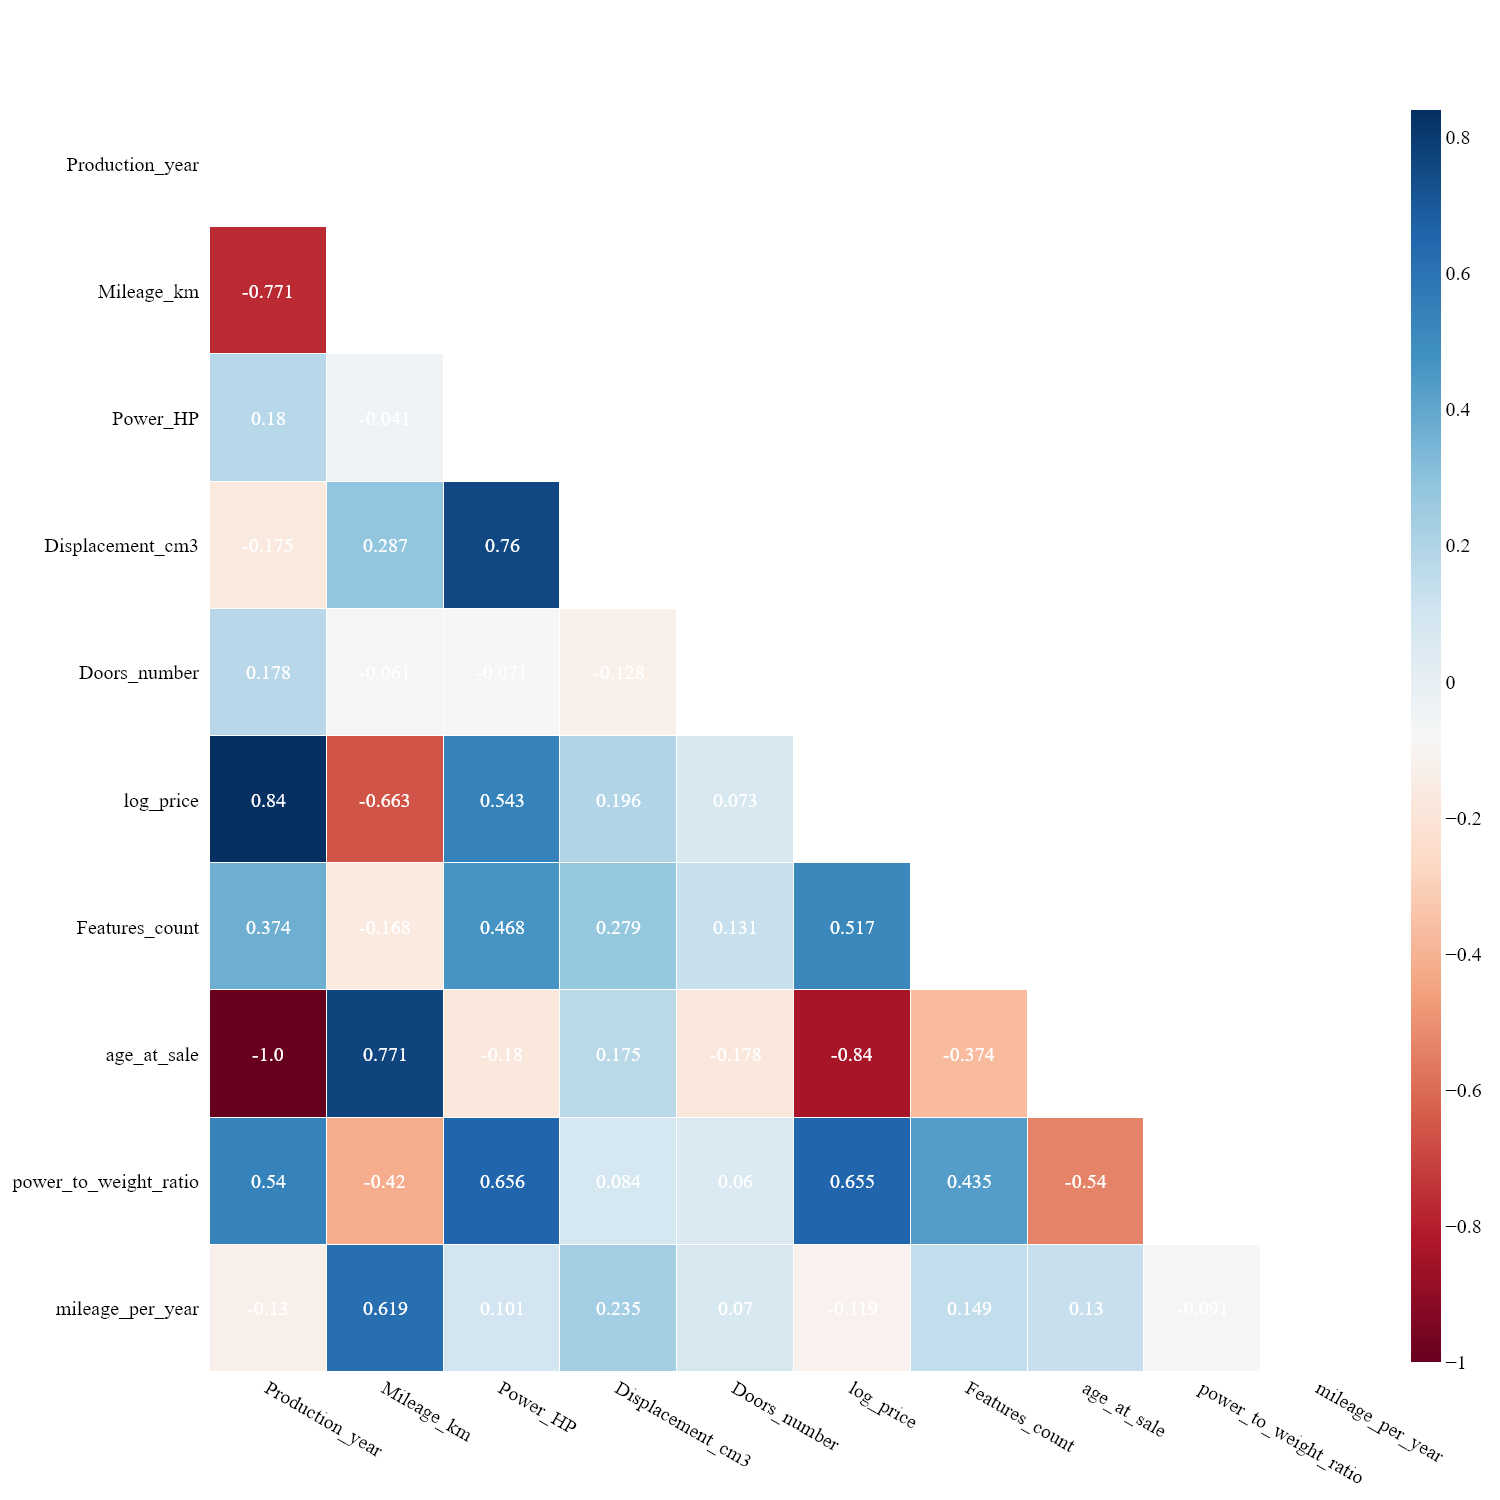

In [68]:
plots.correlation_plot(data[numerical_features], features_names=numerical_features, method="spearman")

**Notes:**

- The correlation matrix reveals that most numerical features have low to moderate correlation with each other.
- A few feature pairs show higher correlations, which may indicate some redundancy or multicollinearity.
- The overall pattern suggests a diverse set of predictors with limited strong linear relationships.

## VIF

To check whether multi-collinearity is present in the dataset, we will calculate the Variance Inflation Factor (VIF) for each continuous feature.

In [69]:
vif_data = pd.DataFrame()
vif_data["feature"] = numerical_features
vif_data["VIF"] = [variance_inflation_factor(data[numerical_features].values, i) for i in range(len(numerical_features))] 
vif_data.sort_values("VIF", ascending=False, inplace=True)
vif_data.reset_index(drop=True, inplace=True)
vif_data

,feature,VIF
0,Production_year,755.567758
1,Power_HP,22.750266
2,age_at_sale,17.463226
3,Displacement_cm3,16.886192
4,power_to_weight_ratio,8.289706
5,log_price,6.261257
6,Mileage_km,4.398205
7,mileage_per_year,1.832481
8,Features_count,1.397222
9,Doors_number,1.139705


**Notes:**

- The VIF table shows that most features have VIF values well below 5, indicating low multicollinearity.
- Only a small number of features approach higher VIF values, which may require further investigation.
- The predictors are generally independent, supporting robust model training.

# Categorical data analysis

## Chi square test

Chi square test is used to determine whether there is a significant association between two categorical variables.

Although our target variable is continous, we can create bins and treat it as categorical feature.

Below we will crate a temporary categorical feature based on target variable and then we will use chi square test to check whether there is a significant association between this temporary feature and other categorical features.

The temporary categorized target will have 5 unique values based on quantiles.

In [70]:
data_temp = data.copy()
data_temp[f"{target_feature}_bins"] = pd.qcut(data_temp[target_feature], q=5, labels=False)
data_temp[f"{target_feature}_bins"].value_counts()

log_price_bins
0    40988
2    40596
4    39954
3    39915
1    39479
Name: count, dtype: int64

In [71]:
class Chi_Square_Test:
    def check_X(
        self, X: pd.DataFrame | pd.Series | np.ndarray
    ) -> np.ndarray:
        """
        Check if X is pandas DataFrame, pandas Series or numpy array and convert it to numpy array.

        Args:
            X: (pd.DataFrame | pd.Series | np.ndarray): input data.

        Returns:
            X: (np.ndarray): converted input data.
        """
        if (
            not isinstance(X, pd.DataFrame)
            and not isinstance(X, pd.Series)
            and not isinstance(X, np.ndarray)
        ):
            raise TypeError(
                "Wrong type of X. It should be pandas DataFrame, pandas Series, numpy array."
            )
        X = np.array(X)
        if X.ndim == 1:
            X = X[None, :]
        return X

    def check_y(
        self, y: pd.DataFrame | pd.Series | np.ndarray
    ) -> np.ndarray:
        """
        Check if y is pandas DataFrame, pandas Series or numpy array and convert it to numpy array.

        Args:
            y: (pd.DataFrame | pd.Series | np.ndarray): target data.

        Returns:
            y: (np.ndarray): converted target data.
        """
        if (
            not isinstance(y, pd.DataFrame)
            and not isinstance(y, pd.Series)
            and not isinstance(y, np.ndarray)
        ):
            raise TypeError(
                "Wrong type of y. It should be pandas DataFrame, pandas Series, numpy array."
            )
        y = np.array(y)
        if y.ndim != 1:
            y = y.squeeze()
        return y

    def check_for_object_columns(self, X: np.ndarray) -> np.ndarray:
        """
        Check if X contains object columns and convert it to numeric data.

        Args:
            X: (np.ndarray): input data.

        Returns:
            X: (np.ndarray): converted input data.
        """
        X = pd.DataFrame(X)
        if X.select_dtypes(include=np.number).shape[1] != X.shape[1]:
            raise TypeError(
                "Your data contains object or string columns. Numeric data is obligated."
            )
        return np.array(X)

    def fit(
        self,
        X: pd.DataFrame | pd.Series | np.ndarray,
        y: pd.DataFrame | pd.Series | np.ndarray,
        alpha: float = 0.05,
    ):
        """
        Perform Chi Square test.

        Args:
            X: (pd.DataFrame | pd.Series | np.ndarray): input data.
            y: (pd.DataFrame | pd.Series | np.ndarray): target data.
            alpha: (float): significance level.
        """
        # X = self.check_X(X)
        # X = self.check_for_object_columns(X)
        # y = self.check_y(y)
        self.crosstab_ = self.crosstab_creation(X=X, y=y)
        self.check_assumptions(crosstab=self.crosstab_)
        self.test_statistic_ = self.calculate_chi_square_statistic(
            crosstab=self.crosstab_
        )
        self.df_ = self.calculate_degrees_of_freedom(crosstab=self.crosstab_)
        self.p_value_ = self.calculate_p_value(
            test_statistic=self.test_statistic_, df=self.df_
        )
        self.critical_value_ = self.calculate_critical_value(df=self.df_, alpha=alpha)
        self.keep_H0 = self.statistical_inference(p_value=self.p_value_, alpha=alpha)
        self.V_Cramera_ = self.calculate_V_Cramera(
            test_statistic=self.test_statistic_, crosstab=self.crosstab_
        )

    def crosstab_creation(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        """
        Create crosstab from input data.

        Args:
            X: (np.ndarray): input data.
            y: (np.ndarray): target data.

        Returns:
            crosstab: (np.ndarray): crosstab.
        """
        return np.array(pd.crosstab(X, y, margins=True))

    def check_assumptions(self, crosstab: np.ndarray) -> bool:
        """
        Check if assumptions for Chi Square test are met.

        Args:
            crosstab: (np.ndarray): crosstab.

        Raises:
            Warning: if assumptions are not met.
        """
        if not all(i <= 5 for i in crosstab.flatten()):
            self.assumption_ = False
            #warnings.warn("Assumptions for Chi Square test are not met.")
        else:
            self.assumption_ = True

    def calculate_chi_square_statistic(self, crosstab: np.ndarray) -> float:
        """
        Calculate Chi Square statistic.

        Args:
            crosstab: (np.ndarray): crosstab.

        Returns:
            chi_square: (float): Chi Square statistic.
        """
        chi_square = 0
        for row in range(0, crosstab.shape[0] - 1):
            for column in range(0, crosstab.shape[1] - 1):
                observed = crosstab[row][column]
                expected = crosstab[row][-1] * crosstab[-1][column] / crosstab[-1][-1]
                chi_square += (observed - expected) ** 2 / expected
        return chi_square

    def calculate_degrees_of_freedom(self, crosstab: np.ndarray) -> int:
        """
        Calculate degrees of freedom.

        Args:
            crosstab: (np.ndarray): crosstab.

        Returns:
            df: (int): degrees of freedom.
        """
        return (crosstab.shape[0] - 2) * (crosstab.shape[1] - 2)

    def calculate_p_value(self, test_statistic: float, df: int) -> float:
        """
        Calculate p value.

        Args:
            test_statistic: (float): test statistic.
            df: (int): degrees of freedom.

        Returns:
            p_value: (float): p value.
        """
        return 1 - chi2.cdf(x=test_statistic, df=df)

    def calculate_critical_value(self, df: int, alpha: float) -> float:
        """
        Calculate critical value.

        Args:
            df: (int): degrees of freedom.
            alpha: (float): significance level.

        Returns:
            critical_value: (float): critical value.
        """
        return chi2.isf(q=alpha, df=df)

    def statistical_inference(self, p_value: float, alpha: float) -> bool:
        """
        Perform statistical inference.

        Args:
            p_value: (float): p value.
            alpha: (float): significance level.

        Returns:
            bool: (bool): True if H0 is not rejected, False otherwise.
        """
        if p_value >= alpha:
            return True
        else:
            return False

    def calculate_V_Cramera(self, test_statistic: float, crosstab: np.ndarray) -> float:
        """
        Calculate V Cramer test statistic.

        Args:
            test_statistic: (float): test statistic.
            crosstab: (np.ndarray): crosstab.

        Returns:
            V_Cramer: (float): V Cramer test statistic.
        """
        return (
            test_statistic
            / (
                crosstab[-1][-1]
                * np.min([crosstab.shape[0] - 2, crosstab.shape[1] - 2])
            )
        ) ** 0.5

chi_square = Chi_Square_Test()

In [72]:
chi_square_results = pd.DataFrame(columns=["Feature", "p_value", "Test statistic", "Critical value", "H0 rejected", "V Cramera"])
for feature in categorical_features:
    chi_square.fit(X=data_temp[feature], y=data_temp[f"{target_feature}_bins"])
    chi_square_results = pd.concat([chi_square_results if not chi_square_results.empty else None, pd.DataFrame({"Feature": [feature], "p_value": [chi_square.p_value_], "Test statistic": [chi_square.test_statistic_], "Critical value": [chi_square.critical_value_], "H0 rejected": [not chi_square.keep_H0], "V Cramera": [chi_square.V_Cramera_]})])
chi_square_results.sort_values(by="Test statistic", ascending=False, inplace=True)
chi_square_results.reset_index(drop=True, inplace=True)
print(f"Percantage of features where H0 is not rejected (features are NOT associated with {target_feature}): {chi_square_results[chi_square_results['H0 rejected'] == False].shape[0]/len(chi_square_results)*100:.2f}%")
print(f"Percantage of features where H0 is rejected (features are associated with {target_feature}): {chi_square_results[chi_square_results['H0 rejected'] == True].shape[0]/len(chi_square_results)*100:.2f}%")
chi_square_results

Percantage of features where H0 is not rejected (features are NOT associated with log_price): 0.00%
Percantage of features where H0 is rejected (features are associated with log_price): 100.00%


,Feature,p_value,Test statistic,Critical value,H0 rejected,V Cramera
0,First_registration_year,0.00000,76856.536048,251.286361,True,0.309233
1,feature_count_bucket,0.00000,68396.000365,21.026070,True,0.336845
2,feature_Bluetooth,0.00000,65942.954783,9.487729,True,0.572875
3,Transmission,0.00000,60814.782698,9.487729,True,0.550149
4,feature_Daytime running lights,0.00000,56859.878836,9.487729,True,0.531959
5,Condition,0.00000,54042.043565,9.487729,True,0.518611
6,Type,0.00000,43903.882913,46.194260,True,0.233721
7,feature_Rear parking sensors,0.00000,37123.167113,9.487729,True,0.429831
8,Origin_country,0.00000,33820.052492,41.337138,True,0.205132
9,feature_Rain sensor,0.00000,30285.306870,9.487729,True,0.388232


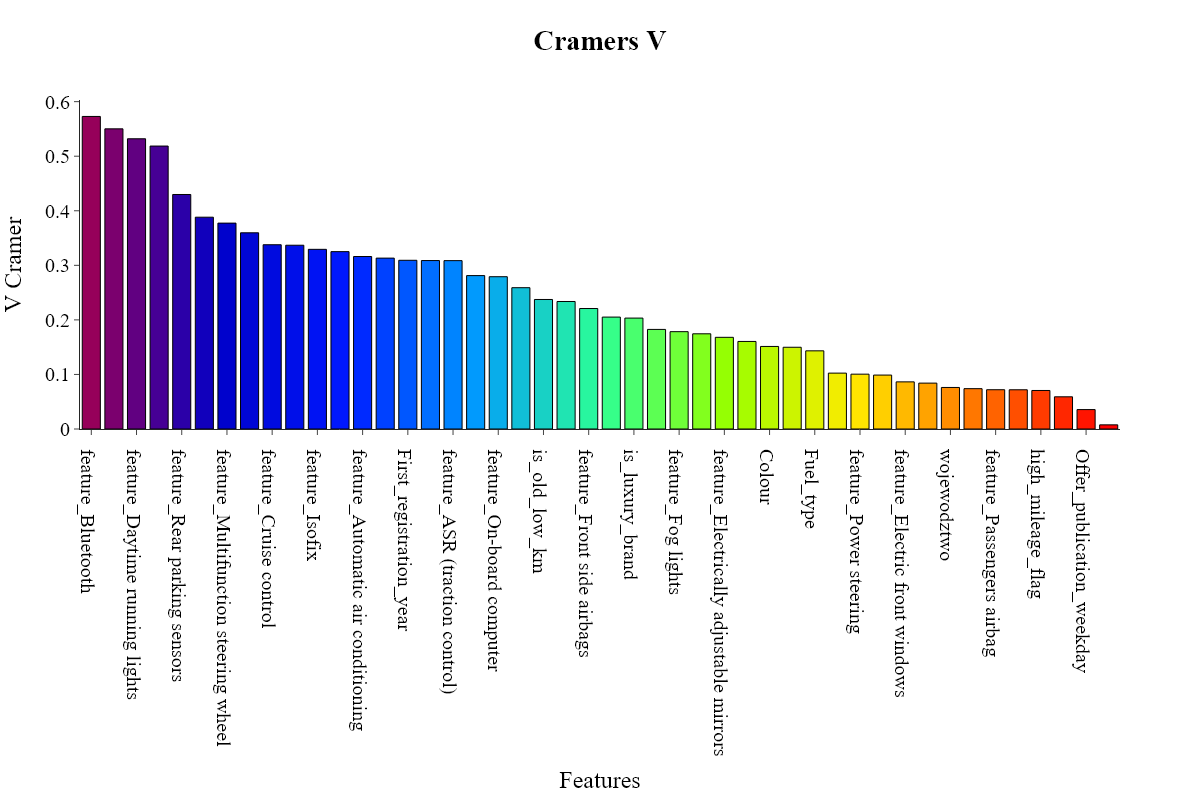

In [73]:
chi_square_results_sorted = chi_square_results.sort_values(by="V Cramera", ascending=False)
fig = go.Figure()
n_colors = len(chi_square_results_sorted)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors - 1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=chi_square_results_sorted["Feature"], y=chi_square_results_sorted["V Cramera"], marker=dict(color=colors, line=dict(color='black', width=1), line_color='black')))
fig.update_xaxes(title_text="Features")
fig.update_yaxes(title_text="V Cramer")
fig.update_layout(template="simple_white", width=1200, height=800, title="<b>Cramers V<b>", title_x=0.5, font=dict(family="Times New Roman", size=20, color="Black"))
fig.show("png")

**Notes:**

- The Cramér's V bar chart highlights which categorical features are most strongly associated with the binned target variable.
- Most features have moderate to high Cramér's V values, indicating meaningful associations with the target.
- Only a few features show weak association, suggesting that most categorical variables are informative for prediction.

## Outliers

Before applying Isolation Forest we will convert categorical features with the usage of pandas `get_dummies` function.

In [76]:
data_temp = data.copy()
data_temp = pd.get_dummies(data_temp, columns=categorical_features, drop_first=True)
data_temp.drop(target_feature, axis=1, inplace=True)

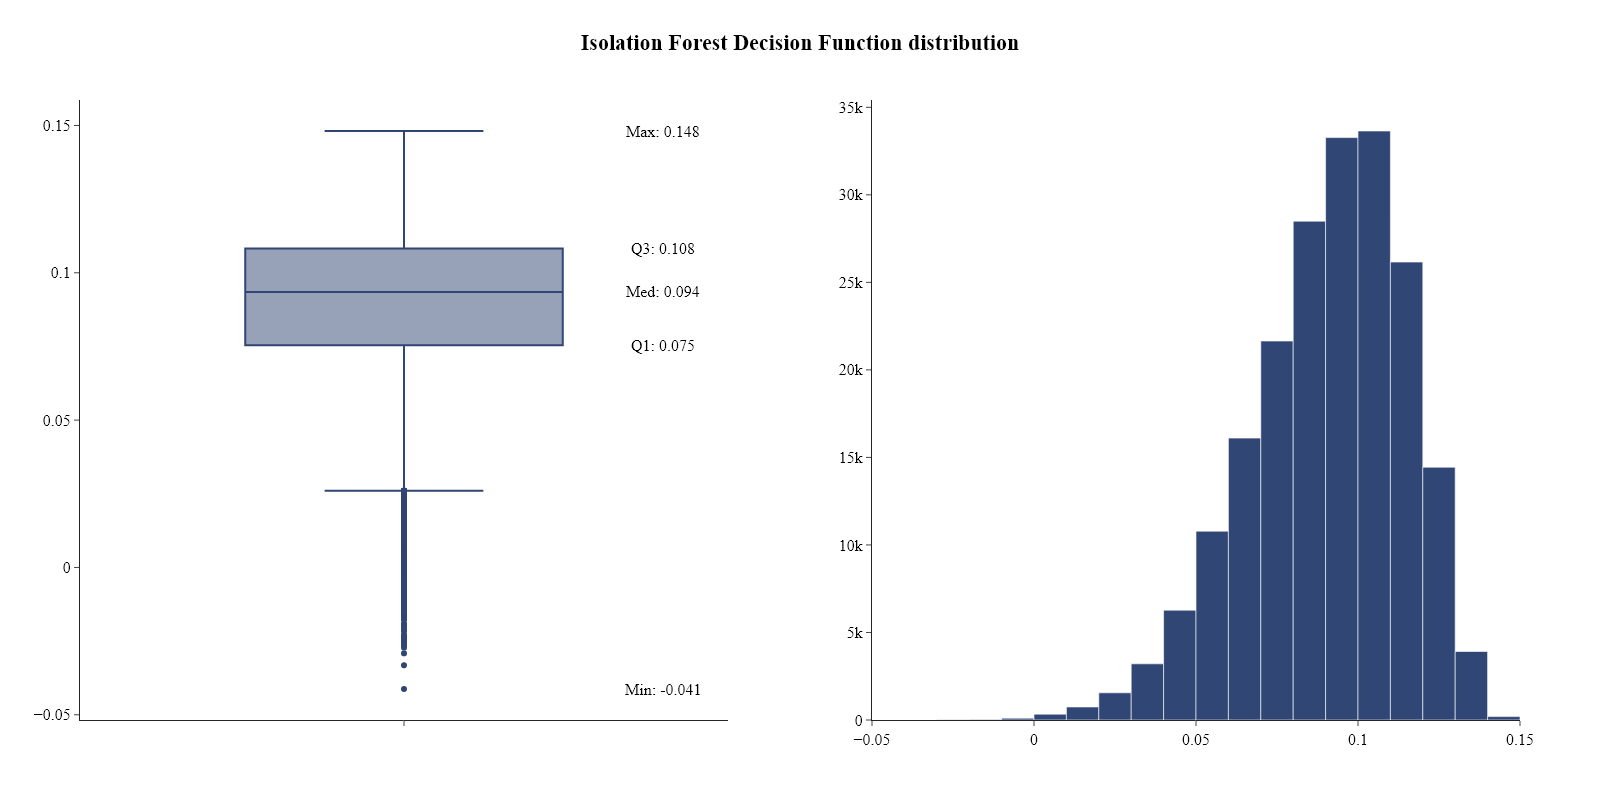

Number of outliers: 156.
Proportion of outliers: 0.08%.


In [77]:
isolation_forest = IsolationForest(random_state=SEED, n_jobs=-1)
isolation_forest.fit(data_temp)
plots.histogram_and_box_plot(data=isolation_forest.decision_function(data_temp), name="Isolation Forest Decision Function", annotations=True, bin_size=0.01)
outliers = isolation_forest.predict(data_temp)
outliers = pd.Series(outliers)
print("Number of outliers: {}.".format(outliers[outliers == -1].shape[0]))
print("Proportion of outliers: {}%.".format(np.round(outliers[outliers == -1].shape[0] / data_temp.shape[0] * 100, 2)))

**Notes:**

Before UMAP which is time consuming I will limit dataset to 10k observations.

In [78]:
data_temp = data_temp.sample(min(data_temp.shape[0], 10000))
outliers = isolation_forest.predict(data_temp)
outliers = pd.Series(outliers)

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



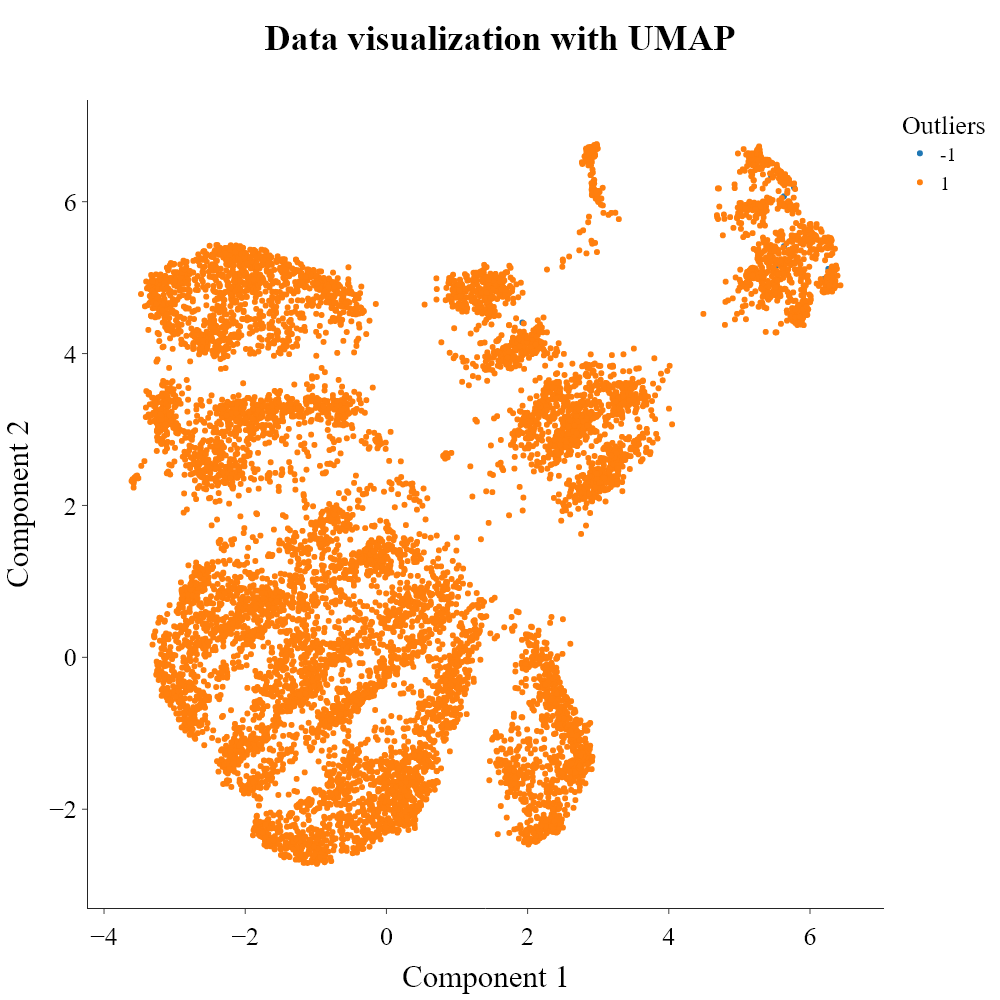

In [79]:
scaler = MinMaxScaler()
umap_model = UMAP(n_components=2, random_state=SEED, n_jobs=-1)
data_temp_scaled = scaler.fit_transform(data_temp)
X_umap = umap_model.fit_transform(data_temp_scaled)
plots.scatter_plot(data=X_umap, hue=outliers, hue_name="Outliers", name="Data visualization with UMAP")

**Notes:**

- The UMAP visualization shows several distinct clusters, indicating underlying structure and grouping in the data.
- Outliers (label -1) are rare and not visually separated from the main data, suggesting that most points are considered inliers by the Isolation Forest.
- The data is well distributed across the two UMAP components, with no single dominant cluster or extreme outlier group.